Om te beginnen gaan we de nodige libraries importeren en de data inladen. De data is opgeslagen in HDF5 formaat, een veelgebruikt formaat voor het opslaan van grote datasets. 
In de dataset zijn er metingen van 104 verschillende autobanden. Van elk van deze banden zijn er van drie onderdelen metingen gedaan. Het loopvlak, innerliner en zijwand. Elke meting bevat een spectrum van intensiteit over een bereik van golflengtes, samen met een timestamp en een order dat aangeeft of de golflengte binnen het ultra violete spectrum valt of binnen zichtbaar licht. Voor elk onderdeel zijn er zo'n 8000 golflengtes gemeten. In totaal hebben wij dus 104 banden * 3 onderdelen = 312 bestanden met elk 254 metingen, oftewel 79368 metingen in totaal.




In [7]:
import pandas as pd
import numpy as np
import h5py
import os
data_directory = 'data'

We beginnen eerst met het inladen van een enkel bestand om de structuur van de data te begrijpen. Later zullen we een loop schrijven om alle bestanden in te laden en samen te voegen tot één grote dataset.



In [8]:
# Load the HDF5 file
with h5py.File(r"data\2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5") as h5:
    intensity = h5['intensity'][:]
    wavelength = h5['wavelength'][:]
    order = h5['order'][:]
    timestamps = h5['timeReceived'][:]
    series = h5['series'][:]

    # Debug: Print shapes to understand the data structure
    print(f"Intensity shape: {intensity.shape}")
    print(f"Wavelength shape: {wavelength.shape}")
    print(f"Order shape: {order.shape}")
    print(f"Timestamps shape: {timestamps.shape}")
    print(f"Series shape: {series.shape}")

# drop the first dimension of timestamps
timestamps = timestamps[1:, :]
timestamps = timestamps.flatten()
print(timestamps.shape)

Intensity shape: (254, 8188)
Wavelength shape: (8188,)
Order shape: (8188,)
Timestamps shape: (2, 254)
Series shape: (1,)
(254,)


De shapes van de ingeladen arrays zijn gelijk dus we kunnen ze samenvoegen tot Pandas dataframe.

In [9]:
# Create DataFrame with wavelengths as index
# Assuming intensity is 2D (time x wavelength), we'll aggregate or take first measurement
if intensity.ndim == 2:
    # Option 1: Take mean intensity across time for each wavelength
    mean_intensity = np.mean(intensity, axis=0)
    
    # Option 2: Take first timestamp measurement
    # first_intensity = intensity[0, :]
    
    # Use mean intensity for now
    intensity_values = mean_intensity
else:
    intensity_values = intensity

# Create DataFrame with wavelengths as index
df = pd.DataFrame(index=wavelength)
df.index.name = 'wavelength'

# Add intensity column
df['intensity'] = intensity_values

# Add order column (should match wavelength length)
if len(order) == len(wavelength):
    df['order'] = order
else:
    print(f"Warning: Order length ({len(order)}) doesn't match wavelength length ({len(wavelength)})")
    # Map order values to wavelengths - assuming order corresponds to channels
    # If order has 2 values (UV, VIS), we need to determine which wavelengths belong to which channel
    if len(order) == 2:
        # This is a simplified mapping - you may need to adjust based on your actual data structure
        df['order'] = np.where(wavelength < 400, order[0], order[1])  # UV < 400nm, VIS >= 400nm
    else:
        df['order'] = 0  # fallback

# Add timestamp column
# Since we have timestamps already processed in the previous cell, we can use those
# But we need to match them to wavelengths somehow
if len(timestamps) == len(wavelength):
    # If timestamps length matches wavelengths (unlikely but possible)
    df['timestamp'] = timestamps
elif len(timestamps) > len(wavelength):
    # Take the mean timestamp or first timestamp for each wavelength
    # This assumes timestamps might be repeated for each wavelength
    chunk_size = len(timestamps) // len(wavelength)
    if chunk_size > 0:
        reshaped_timestamps = timestamps[:len(wavelength) * chunk_size].reshape(len(wavelength), -1)
        df['timestamp'] = pd.to_datetime(np.mean(reshaped_timestamps, axis=1), unit='us')
    else:
        df['timestamp'] = timestamps[:len(wavelength)]
else:
    print(f"Warning: Cannot align timestamps (length {len(timestamps)}) with wavelengths (length {len(wavelength)})")
    # Use a single representative timestamp for all wavelengths
    df['timestamp'] = timestamps[0] if len(timestamps) > 0 else pd.NaT

print("DataFrame structure:")
print(df.head())
print(f"\nDataFrame shape: {df.shape}")
print(f"Index (wavelengths): {len(df.index)} values")
print(f"Timestamps type: {type(df['timestamp'].iloc[0]) if not df['timestamp'].isna().all() else 'All NaT'}")

DataFrame structure:
             intensity  order         timestamp
wavelength                                     
184.261658  178.610236      0  1730802401319208
184.334961  137.649606      0  1730802401319208
184.408279  207.807087      0  1730802401319208
184.481567  156.586614      0  1730802401319208
184.554886  227.283465      0  1730802401319208

DataFrame shape: (8188, 3)
Index (wavelengths): 8188 values
Timestamps type: <class 'numpy.int64'>


In [10]:
df.info(verbose=True)
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 8188 entries, 184.26165771484375 to 982.356201171875
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   intensity  8188 non-null   float64
 1   order      8188 non-null   int8   
 2   timestamp  8188 non-null   int64  
dtypes: float64(1), int64(1), int8(1)
memory usage: 167.9 KB


,intensity,order,timestamp
count,8188.000000,8188.000000,8.188000e+03
mean,11873.560111,0.500000,1.730802e+15
std,8956.196709,0.500031,2.500153e-01
min,110.094488,0.000000,1.730802e+15
25%,4287.270669,0.000000,1.730802e+15
50%,10427.173228,0.500000,1.730802e+15
75%,18531.391732,1.000000,1.730802e+15
max,62745.996063,1.000000,1.730802e+15


Zo nu hebben wij een dataframe met alle metingen van een het loopvlak van de eerste band. Met een simpele plot gaan we checken of de data er logisch uitziet en dit een goede manier is om de data op te slaan.

<Axes: title={'center': 'Intensity vs Wavelength'}, xlabel='wavelength'>

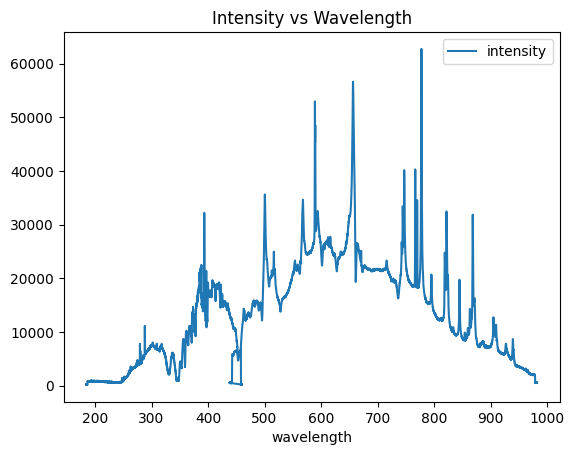

In [11]:
df.plot(y='intensity', kind='line', title='Intensity vs Wavelength')

Dit ziet er goed uit. Nu gaan we de data verdelen over de drie onderdelen van de band om de datakwaliteit te checken

In [12]:
# Lists for each category
tread_files = []
innerliner_files = []
sidewall_files = []

# Loop through all files in the directory
for filename in os.listdir(data_directory):
    filepath = os.path.join(data_directory, filename)

    # Skip if it's not a file (ignore subfolders)
    if not os.path.isfile(filepath):
        continue

    # Categorize based on filename
    if "tread" in filename.lower():
        tread_files.append(filepath)
    elif "innerliner" in filename.lower():
        innerliner_files.append(filepath)
    elif "sidewall" in filename.lower():
        sidewall_files.append(filepath)

#Results
print("Tread files:", len(tread_files))
print("Innerliner files:", len(innerliner_files))
print("Sidewall files:", len(sidewall_files))
# Example: Process the first file in each category
example_files = [tread_files[0], innerliner_files[0], sidewall_files[0]]
print("Example files to process:", example_files)

Tread files: 104
Innerliner files: 104
Sidewall files: 104
Example files to process: ['data\\2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5', 'data\\2024-11-05T11-28-40_nr-002_B1_innerliner_aided_10Hz_280A.h5', 'data\\2024-11-05T11-30-22_nr-003_B1_sidewall_aided_10Hz_280A.h5']


Dat is gelukt. Nu wil ik de data gaan visualiseren om te checken of er geen vreemde uitschieters in de data zitten.

In [13]:
# Function to extract tire number from filename
import re

def extract_tire_number(filename):
    """Extract tire number from filename like '2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5'"""
    # Look for pattern like 'B1', 'B2', etc.
    match = re.search(r'_B(\d+)_', filename)
    if match:
        return int(match.group(1))
    else:
        # Fallback: look for any number pattern
        match = re.search(r'nr-(\d+)', filename)
        if match:
            return int(match.group(1))
    return None

# Create combined DataFrame for all tread data
all_tread_dfs = []

print(f"Processing {len(tread_files)} tread files...")

for i, filepath in enumerate(tread_files):
    try:
        filename = os.path.basename(filepath)
        tire_number = extract_tire_number(filename)
        
        # Load the HDF5 file
        with h5py.File(filepath) as h5:
            intensity = h5['intensity'][:]
            wavelength = h5['wavelength'][:]
            order = h5['order'][:]
            timestamps = h5['timeReceived'][:]
        
        # Process data similar to what we did before
        if intensity.ndim == 2:
            mean_intensity = np.mean(intensity, axis=0)
        else:
            mean_intensity = intensity
        
        # Create DataFrame for this file
        file_df = pd.DataFrame(index=wavelength)
        file_df.index.name = 'wavelength'
        file_df['intensity'] = mean_intensity
        
        # Add order column
        if len(order) == len(wavelength):
            file_df['order'] = order
        else:
            # Map order values based on wavelength ranges
            if len(order) == 2:
                file_df['order'] = np.where(wavelength < 400, order[0], order[1])
            else:
                file_df['order'] = 0
        
        # Add tire number
        file_df['tire_number'] = tire_number
        
        # Add timestamp (use mean timestamp for this file)
        if timestamps.ndim == 2:
            timestamps_flat = timestamps[1:, :].flatten()  # Drop first dimension like before
            mean_timestamp = np.mean(timestamps_flat)
            file_df['timestamp'] = pd.to_datetime(mean_timestamp, unit='us')
        else:
            file_df['timestamp'] = pd.to_datetime(np.mean(timestamps), unit='us')
        
        all_tread_dfs.append(file_df)
        
        if (i + 1) % 10 == 0:  # Progress indicator
            print(f"Processed {i + 1}/{len(tread_files)} files...")
            
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        continue

# Combine all DataFrames
if all_tread_dfs:
    tread_df = pd.concat(all_tread_dfs, ignore_index=False)
    print(f"\nCombined DataFrame created!")
    print(f"Shape: {tread_df.shape}")
    print(f"Unique tire numbers: {sorted(tread_df['tire_number'].unique())}")
    print(f"Tire count: {tread_df['tire_number'].nunique()}")
    print("\nFirst few rows:")
    print(tread_df.head())
else:
    print("No data was successfully processed!")

Processing 104 tread files...
Processed 10/104 files...
Processed 20/104 files...
Processed 30/104 files...
Processed 40/104 files...
Processed 50/104 files...
Processed 60/104 files...
Processed 70/104 files...
Processed 80/104 files...
Processed 90/104 files...
Processed 100/104 files...

Combined DataFrame created!
Shape: (851552, 4)
Unique tire numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104]
Tire count: 103

First few rows:
             intensity  order  tire_number                     timestamp
wavelength                                                              
184.261658  178.610236      0            1 2024-11-0

In [14]:
# Analyze the combined tread DataFrame
print("=== TREAD DATA ANALYSIS ===")
print(f"Total rows: {len(tread_df):,}")
print(f"Total columns: {len(tread_df.columns)}")
print(f"Memory usage: {tread_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nTire numbers found: {tread_df['tire_number'].nunique()}")
print(f"Tire number range: {tread_df['tire_number'].min()} - {tread_df['tire_number'].max()}")

print(f"\nWavelength range: {tread_df.index.min():.2f} - {tread_df.index.max():.2f} nm")
print(f"Intensity range: {tread_df['intensity'].min():.2f} - {tread_df['intensity'].max():.2f}")

print("\nData types:")
print(tread_df.dtypes)

print("\nSample of data by tire number:")
print(tread_df.groupby('tire_number').agg({
    'intensity': ['count', 'mean', 'std']
}).head())

# If you need wavelength statistics per tire, access the index:
print("\nWavelength range per tire (first 5):")
wavelength_stats = tread_df.groupby('tire_number').apply(
    lambda x: f"{x.index.min():.1f}-{x.index.max():.1f}"
).head()
print(wavelength_stats)

=== TREAD DATA ANALYSIS ===
Total rows: 851,552
Total columns: 4
Memory usage: 23.55 MB

Tire numbers found: 103
Tire number range: 1 - 104

Wavelength range: 184.26 - 982.36 nm
Intensity range: 97.67 - 65303.42

Data types:
intensity             float64
order                    int8
tire_number             int64
timestamp      datetime64[ns]
dtype: object

Sample of data by tire number:
            intensity                            
                count          mean           std
tire_number                                      
1                8188  11873.560111   8956.196709
2                8188   8435.755562   6616.528135
3                8188  11973.879058   8972.980279
4                8188  11781.213984   9369.338475
5                8188  13165.606673  10079.393566

Wavelength range per tire (first 5):
tire_number
1    184.3-982.4
2    184.3-982.4
3    184.3-982.4
4    184.3-982.4
5    184.3-982.4
dtype: object


C:\Users\joost\AppData\Local\Temp\ipykernel_20312\3304879573.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wavelength_stats = tread_df.groupby('tire_number').apply(


## Process Innerliner Data
Now let's process all the innerliner files and create a combined DataFrame.

In [15]:
# Create combined DataFrame for all innerliner data
all_innerliner_dfs = []

print(f"Processing {len(innerliner_files)} innerliner files...")

for i, filepath in enumerate(innerliner_files):
    try:
        filename = os.path.basename(filepath)
        tire_number = extract_tire_number(filename)
        
        # Load the HDF5 file
        with h5py.File(filepath) as h5:
            intensity = h5['intensity'][:]
            wavelength = h5['wavelength'][:]
            order = h5['order'][:]
            timestamps = h5['timeReceived'][:]
        
        # Process data similar to what we did before
        if intensity.ndim == 2:
            mean_intensity = np.mean(intensity, axis=0)
        else:
            mean_intensity = intensity
        
        # Create DataFrame for this file
        file_df = pd.DataFrame(index=wavelength)
        file_df.index.name = 'wavelength'
        file_df['intensity'] = mean_intensity
        
        # Add order column
        if len(order) == len(wavelength):
            file_df['order'] = order
        else:
            # Map order values based on wavelength ranges
            if len(order) == 2:
                file_df['order'] = np.where(wavelength < 400, order[0], order[1])
            else:
                file_df['order'] = 0
        
        # Add tire number
        file_df['tire_number'] = tire_number
        
        # Add timestamp (use mean timestamp for this file)
        if timestamps.ndim == 2:
            timestamps_flat = timestamps[1:, :].flatten()  # Drop first dimension like before
            mean_timestamp = np.mean(timestamps_flat)
            file_df['timestamp'] = pd.to_datetime(mean_timestamp, unit='us')
        else:
            file_df['timestamp'] = pd.to_datetime(np.mean(timestamps), unit='us')
        
        all_innerliner_dfs.append(file_df)
        
        if (i + 1) % 10 == 0:  # Progress indicator
            print(f"Processed {i + 1}/{len(innerliner_files)} files...")
            
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        continue

# Combine all DataFrames
if all_innerliner_dfs:
    innerliner_df = pd.concat(all_innerliner_dfs, ignore_index=False)
    print(f"\nCombined Innerliner DataFrame created!")
    print(f"Shape: {innerliner_df.shape}")
    print(f"Unique tire numbers: {sorted(innerliner_df['tire_number'].unique())}")
    print(f"Tire count: {innerliner_df['tire_number'].nunique()}")
    print("\nFirst few rows:")
    print(innerliner_df.head())
else:
    print("No innerliner data was successfully processed!")

Processing 104 innerliner files...
Processed 10/104 files...
Processed 20/104 files...
Processed 30/104 files...
Processed 40/104 files...
Processed 50/104 files...
Processed 60/104 files...
Processed 70/104 files...
Processed 80/104 files...
Processed 90/104 files...
Processed 100/104 files...

Combined Innerliner DataFrame created!
Shape: (851552, 4)
Unique tire numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104]
Tire count: 103

First few rows:
             intensity  order  tire_number                  timestamp
wavelength                                                           
184.261658  176.964444      0            1

## Process Sidewall Data
Now let's process all the sidewall files and create a combined DataFrame.

In [16]:
# Create combined DataFrame for all sidewall data
all_sidewall_dfs = []

print(f"Processing {len(sidewall_files)} sidewall files...")

for i, filepath in enumerate(sidewall_files):
    try:
        filename = os.path.basename(filepath)
        tire_number = extract_tire_number(filename)
        
        # Load the HDF5 file
        with h5py.File(filepath) as h5:
            intensity = h5['intensity'][:]
            wavelength = h5['wavelength'][:]
            order = h5['order'][:]
            timestamps = h5['timeReceived'][:]
        
        # Process data similar to what we did before
        if intensity.ndim == 2:
            mean_intensity = np.mean(intensity, axis=0)
        else:
            mean_intensity = intensity
        
        # Create DataFrame for this file
        file_df = pd.DataFrame(index=wavelength)
        file_df.index.name = 'wavelength'
        file_df['intensity'] = mean_intensity
        
        # Add order column
        if len(order) == len(wavelength):
            file_df['order'] = order
        else:
            # Map order values based on wavelength ranges
            if len(order) == 2:
                file_df['order'] = np.where(wavelength < 400, order[0], order[1])
            else:
                file_df['order'] = 0
        
        # Add tire number
        file_df['tire_number'] = tire_number
        
        # Add timestamp (use mean timestamp for this file)
        if timestamps.ndim == 2:
            timestamps_flat = timestamps[1:, :].flatten()  # Drop first dimension like before
            mean_timestamp = np.mean(timestamps_flat)
            file_df['timestamp'] = pd.to_datetime(mean_timestamp, unit='us')
        else:
            file_df['timestamp'] = pd.to_datetime(np.mean(timestamps), unit='us')
        
        all_sidewall_dfs.append(file_df)
        
        if (i + 1) % 10 == 0:  # Progress indicator
            print(f"Processed {i + 1}/{len(sidewall_files)} files...")
            
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        continue

# Combine all DataFrames
if all_sidewall_dfs:
    sidewall_df = pd.concat(all_sidewall_dfs, ignore_index=False)
    print(f"\nCombined Sidewall DataFrame created!")
    print(f"Shape: {sidewall_df.shape}")
    print(f"Unique tire numbers: {sorted(sidewall_df['tire_number'].unique())}")
    print(f"Tire count: {sidewall_df['tire_number'].nunique()}")
    print("\nFirst few rows:")
    print(sidewall_df.head())
else:
    print("No sidewall data was successfully processed!")

Processing 104 sidewall files...


Processed 10/104 files...
Processed 20/104 files...
Processed 30/104 files...
Processed 40/104 files...
Processed 50/104 files...
Processed 60/104 files...
Processed 70/104 files...
Processed 80/104 files...
Processed 90/104 files...
Processed 100/104 files...

Combined Sidewall DataFrame created!
Shape: (851552, 4)
Unique tire numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104]
Tire count: 102

First few rows:
             intensity  order  tire_number                  timestamp
wavelength                                                           
184.261658  176.351916      0            1 2024-11-05 10:30:36.947857
184.334961  1

## Summary of All Datasets
Let's compare the three datasets and create a comprehensive overview.

In [17]:
# Summary comparison of all three datasets
datasets = {
    'Tread': tread_df,
    'Innerliner': innerliner_df,
    'Sidewall': sidewall_df
}

print("=== DATASET COMPARISON ===")
print(f"{'Dataset':<12} {'Rows':<10} {'Tires':<6} {'Memory (MB)':<12} {'Intensity Range':<20}")
print("-" * 70)

for name, df in datasets.items():
    if 'df' in locals() and df is not None:
        memory_mb = df.memory_usage(deep=True).sum() / 1024**2
        intensity_range = f"{df['intensity'].min():.2f} - {df['intensity'].max():.2f}"
        print(f"{name:<12} {len(df):<10,} {df['tire_number'].nunique():<6} {memory_mb:<12.2f} {intensity_range:<20}")

print(f"\nTotal files processed: {len(tread_files) + len(innerliner_files) + len(sidewall_files)}")
print(f"Expected total: 104 tires × 3 parts = 312 files")

# Check for any missing tires across datasets
all_tire_numbers = set()
for name, df in datasets.items():
    if 'df' in locals() and df is not None:
        tire_numbers = set(df['tire_number'].unique())
        all_tire_numbers.update(tire_numbers)
        print(f"\n{name} tire numbers: {sorted(tire_numbers)}")

print(f"\nAll unique tire numbers across datasets: {sorted(all_tire_numbers)}")
print(f"Total unique tires found: {len(all_tire_numbers)}")

# Check data consistency
print("\n=== DATA CONSISTENCY CHECK ===")
wavelength_ranges = {}
for name, df in datasets.items():
    if 'df' in locals() and df is not None:
        wl_min, wl_max = df.index.min(), df.index.max()
        wavelength_ranges[name] = (wl_min, wl_max)
        print(f"{name} wavelength range: {wl_min:.2f} - {wl_max:.2f} nm")

# Check if all datasets have the same wavelength range
ranges = list(wavelength_ranges.values())
if len(set(ranges)) == 1:
    print("✓ All datasets have consistent wavelength ranges")
else:
    print("⚠ Wavelength ranges differ between datasets")

=== DATASET COMPARISON ===
Dataset      Rows       Tires  Memory (MB)  Intensity Range     
----------------------------------------------------------------------
Tread        851,552    103    23.55        97.67 - 65303.42    
Innerliner   851,552    103    23.55        97.71 - 65511.19    
Sidewall     851,552    102    23.55        98.11 - 65371.09    

Total files processed: 312
Expected total: 104 tires × 3 parts = 312 files

Tread tire numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104]

Innerliner tire numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31

In [18]:
# Concatenate all data for a full overview with origin column
# First, add the origin column to each DataFrame
tread_df_with_origin = tread_df.copy()
tread_df_with_origin['origin'] = 'tread'

innerliner_df_with_origin = innerliner_df.copy()
innerliner_df_with_origin['origin'] = 'innerliner'

sidewall_df_with_origin = sidewall_df.copy()
sidewall_df_with_origin['origin'] = 'sidewall'

# Concatenate all DataFrames
full_df = pd.concat([
    tread_df_with_origin,
    innerliner_df_with_origin,
    sidewall_df_with_origin
], ignore_index=False)  # Keep the wavelength index

print("=== COMBINED DATASET OVERVIEW ===")
print(f"Total rows: {len(full_df):,}")
print(f"Total columns: {len(full_df.columns)}")
print(f"Memory usage: {full_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nBreakdown by origin:")
origin_counts = full_df['origin'].value_counts()
print(origin_counts)

print(f"\nBreakdown by tire number:")
tire_counts = full_df['tire_number'].value_counts().sort_index()
print(f"Unique tires: {full_df['tire_number'].nunique()}")
print(f"Tire range: {full_df['tire_number'].min()} - {full_df['tire_number'].max()}")

print(f"\nSample of combined data:")
print(full_df.head())

print(f"\nData types:")
print(full_df.dtypes)

=== COMBINED DATASET OVERVIEW ===
Total rows: 2,554,656
Total columns: 5
Memory usage: 228.20 MB

Breakdown by origin:
origin
tread         851552
innerliner    851552
sidewall      851552
Name: count, dtype: int64

Breakdown by tire number:
Unique tires: 103
Tire range: 1 - 104

Sample of combined data:
             intensity  order  tire_number                     timestamp  \
wavelength                                                                 
184.261658  178.610236      0            1 2024-11-05 10:26:53.968442250   
184.334961  137.649606      0            1 2024-11-05 10:26:53.968442250   
184.408279  207.807087      0            1 2024-11-05 10:26:53.968442250   
184.481567  156.586614      0            1 2024-11-05 10:26:53.968442250   
184.554886  227.283465      0            1 2024-11-05 10:26:53.968442250   

           origin  
wavelength         
184.261658  tread  
184.334961  tread  
184.408279  tread  
184.481567  tread  
184.554886  tread  

Data types:
intensit

In [19]:
# Analysis of the combined dataset
print("=== COMBINED DATASET ANALYSIS ===")

# Check completeness - should have 3 records per tire (tread, innerliner, sidewall)
tire_origin_crosstab = pd.crosstab(full_df['tire_number'], full_df['origin'])
print("\nTire × Origin crosstab (showing first 10 tires):")
print(tire_origin_crosstab.head(10))

# Check for missing combinations
incomplete_tires = tire_origin_crosstab[
    (tire_origin_crosstab['innerliner'] == 0) | 
    (tire_origin_crosstab['sidewall'] == 0) | 
    (tire_origin_crosstab['tread'] == 0)
]

if len(incomplete_tires) > 0:
    print(f"\n⚠️ Found {len(incomplete_tires)} tires with missing data:")
    print(incomplete_tires)
else:
    print("\n✅ All tires have complete data for all three components")

# Intensity statistics by origin
print("\nIntensity statistics by origin:")
intensity_stats = full_df.groupby('origin')['intensity'].agg(['count', 'mean', 'std', 'min', 'max'])
print(intensity_stats)

# Wavelength consistency check
print("\nWavelength range consistency:")
for origin in full_df['origin'].unique():
    origin_data = full_df[full_df['origin'] == origin]
    wl_min, wl_max = origin_data.index.min(), origin_data.index.max()
    print(f"{origin:12}: {wl_min:.2f} - {wl_max:.2f} nm ({len(origin_data.index.unique())} unique wavelengths)")

print(f"\nDataset ready for machine learning!")
print(f"Features available: wavelength (index), intensity, order, tire_number, timestamp, origin")
print(f"Potential target variable: origin (for classification)")
print(f"Total samples: {len(full_df):,} spectral measurements")

=== COMBINED DATASET ANALYSIS ===

Tire × Origin crosstab (showing first 10 tires):
origin       innerliner  sidewall  tread
tire_number                             
1                  8188      8188   8188
2                  8188      8188   8188
3                  8188      8188   8188
4                  8188      8188   8188
5                  8188      8188   8188
6                  8188      8188   8188
7                  8188      8188   8188
8                  8188      8188   8188
9                  8188      8188   8188
10                 8188      8188   8188

⚠️ Found 1 tires with missing data:
origin       innerliner  sidewall  tread
tire_number                             
90                 8188         0   8188

Intensity statistics by origin:
             count          mean          std        min           max
origin                                                                
innerliner  851552  10400.160786  9007.978993  97.709402  65511.189944
sidewall    851552

## Data Visualization
Let's explore different ways to visualize the intensity per wavelength for our LIBS spectral data.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

### 1. Single Spectrum Plot
First, let's visualize the spectrum for a single tire to understand the basic structure.

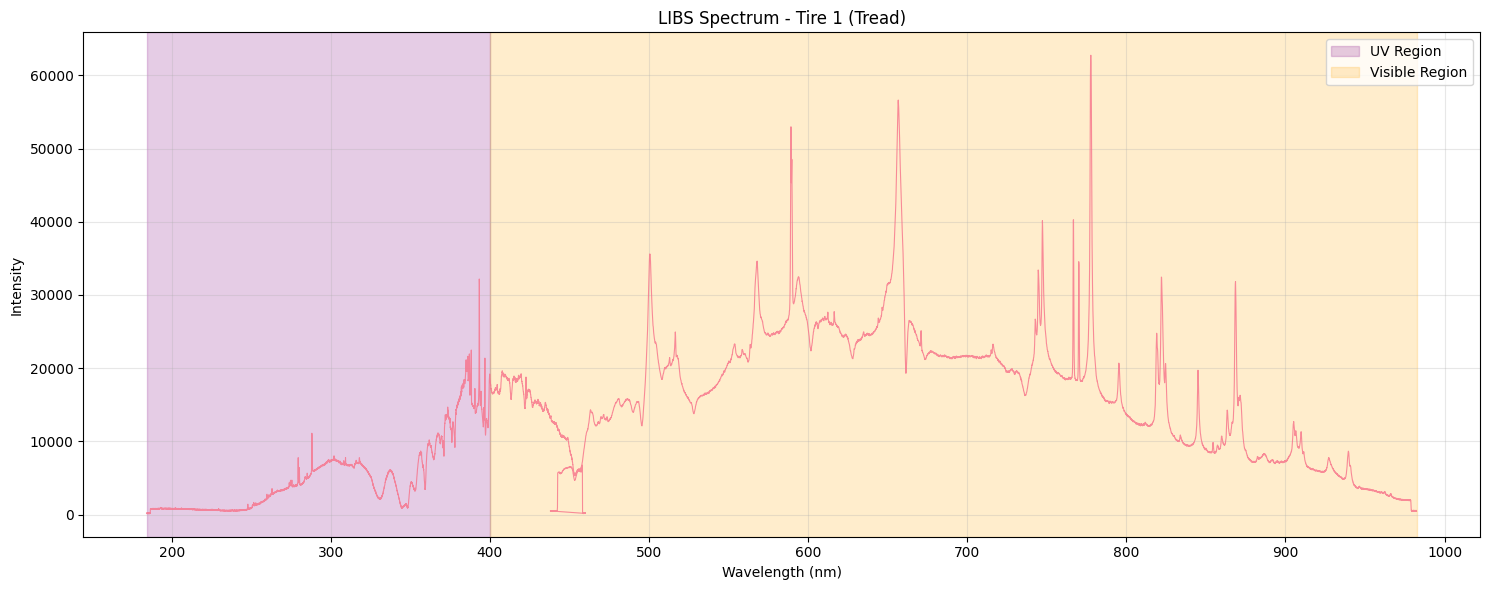

Wavelength range: 184.3 - 982.4 nm
Intensity range: 110.1 - 62746.0
Peak intensity at wavelength: 777.7 nm


In [21]:
# Plot spectrum for a single tire (tread data)
single_tire = tread_df[tread_df['tire_number'] == 1].copy()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(single_tire.index, single_tire['intensity'], linewidth=0.8, alpha=0.8)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title('LIBS Spectrum - Tire 1 (Tread)')
ax.grid(True, alpha=0.3)

# Highlight UV vs VIS regions
uv_region = single_tire[single_tire.index < 400]
vis_region = single_tire[single_tire.index >= 400]

ax.axvspan(single_tire.index.min(), 400, alpha=0.2, color='purple', label='UV Region')
ax.axvspan(400, single_tire.index.max(), alpha=0.2, color='orange', label='Visible Region')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Wavelength range: {single_tire.index.min():.1f} - {single_tire.index.max():.1f} nm")
print(f"Intensity range: {single_tire['intensity'].min():.1f} - {single_tire['intensity'].max():.1f}")
print(f"Peak intensity at wavelength: {single_tire.index[single_tire['intensity'].argmax()]:.1f} nm")

### 2. Multiple Tire Comparison
Compare spectra from different tires to see variability.

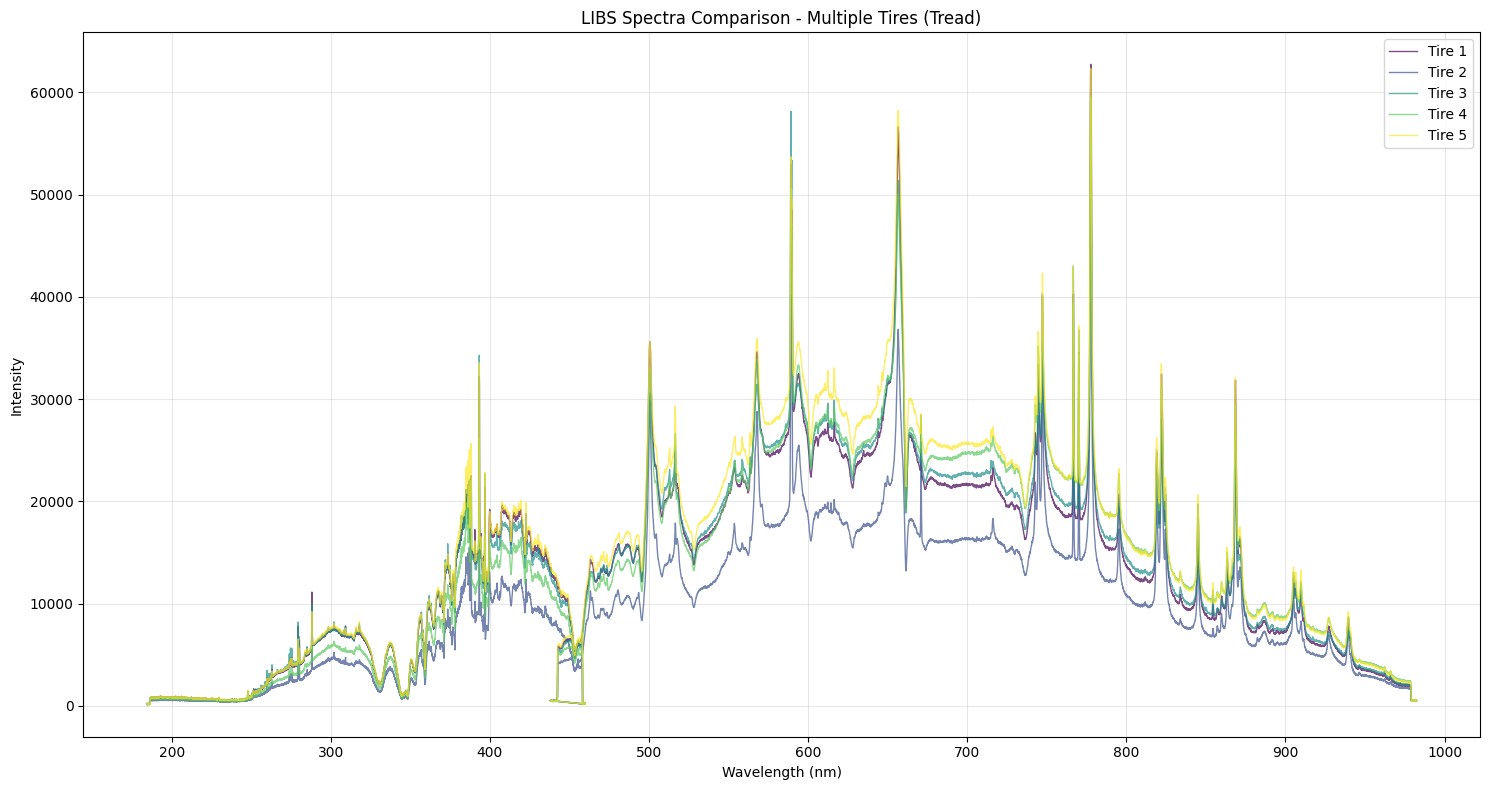

Intensity statistics by tire:
                     mean           std         min           max
tire_number                                                      
1            11873.560111   8956.196709  110.094488  62745.996063
2             8435.755562   6616.528135  106.917582  60172.681319
3            11973.879058   8972.980279  103.071795  58149.548718
4            11781.213984   9369.338475  103.589286  59522.656250
5            13165.606673  10079.393566  115.028571  62342.866667


In [22]:
# Compare spectra from different tires (first 5 tires)
fig, ax = plt.subplots(figsize=(15, 8))

tire_numbers = sorted(tread_df['tire_number'].unique())[:5]
colors = plt.cm.viridis(np.linspace(0, 1, len(tire_numbers)))

for i, tire_num in enumerate(tire_numbers):
    tire_data = tread_df[tread_df['tire_number'] == tire_num]
    ax.plot(tire_data.index, tire_data['intensity'], 
            label=f'Tire {tire_num}', alpha=0.7, color=colors[i], linewidth=1)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title('LIBS Spectra Comparison - Multiple Tires (Tread)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical summary
print("Intensity statistics by tire:")
stats = tread_df.groupby('tire_number')['intensity'].agg(['mean', 'std', 'min', 'max']).head()
print(stats)

### 3. Heatmap Visualization
Show intensity patterns across all tires and wavelengths.

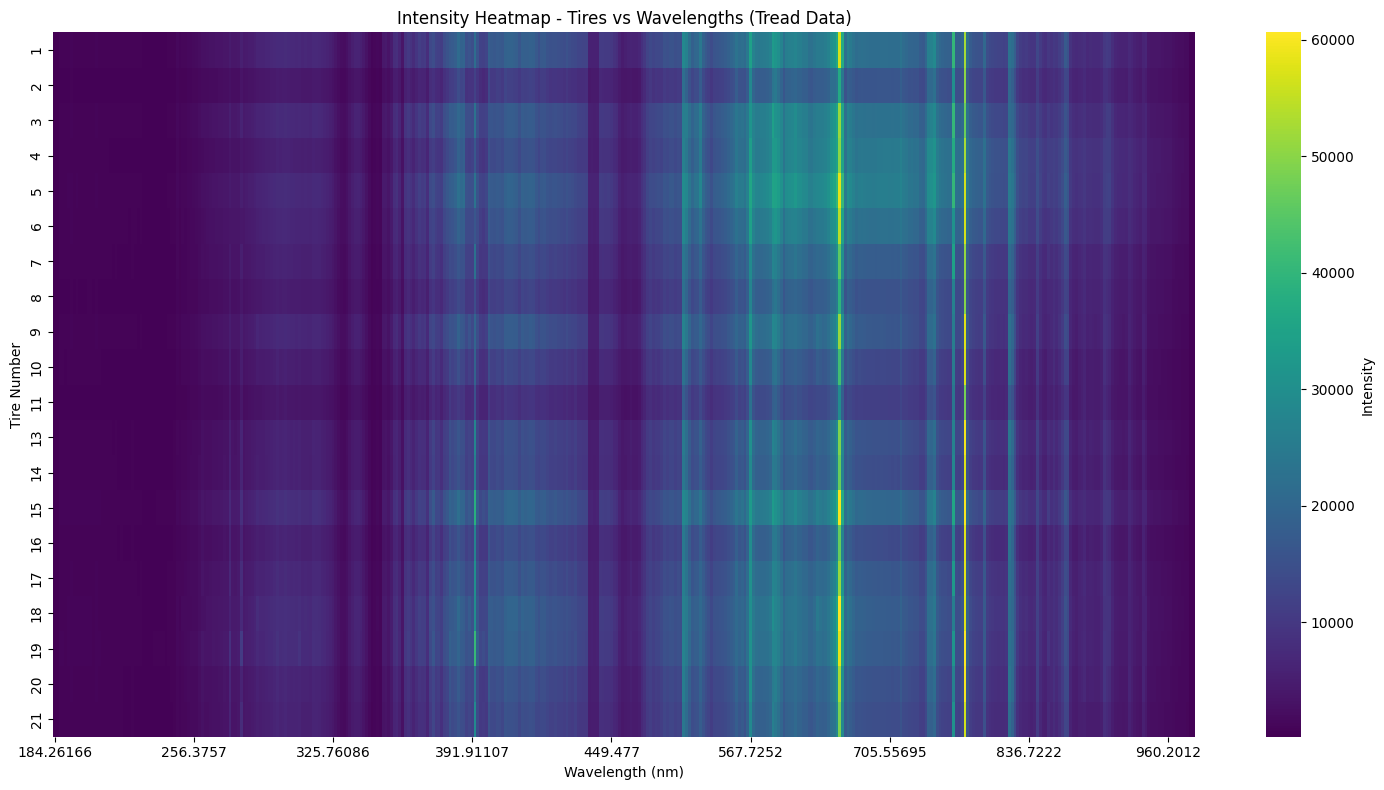

Heatmap shows 20 tires and 410 wavelength points


In [23]:
# Create heatmap of intensity across tires and wavelengths (subset for performance)
# Sample every 10th wavelength and first 20 tires for visualization
subset_tires = sorted(tread_df['tire_number'].unique())[:20]
subset_data = tread_df[tread_df['tire_number'].isin(subset_tires)]

# Create pivot table for heatmap
pivot_data = subset_data.reset_index().pivot_table(
    index='tire_number', 
    columns='wavelength', 
    values='intensity'
)

# Sample every 20th wavelength for better visualization
sampled_wavelengths = pivot_data.columns[::20]
pivot_sampled = pivot_data[sampled_wavelengths]

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_sampled, 
            cmap='viridis', 
            cbar_kws={'label': 'Intensity'},
            xticklabels=50,  # Show every 50th wavelength label
            yticklabels=True)
plt.title('Intensity Heatmap - Tires vs Wavelengths (Tread Data)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Tire Number')
plt.tight_layout()
plt.show()

print(f"Heatmap shows {len(subset_tires)} tires and {len(sampled_wavelengths)} wavelength points")

### 4. Interactive Plotly Visualization
Create an interactive plot for exploring the data.

In [24]:
# Interactive plot with multiple tires
fig = go.Figure()

# Add traces for first 10 tires
sample_tires = sorted(tread_df['tire_number'].unique())[:10]

for tire_num in sample_tires:
    tire_data = tread_df[tread_df['tire_number'] == tire_num]
    
    fig.add_trace(go.Scatter(
        x=tire_data.index,
        y=tire_data['intensity'],
        mode='lines',
        name=f'Tire {tire_num}',
        line=dict(width=1),
        opacity=0.8
    ))

fig.update_layout(
    title='Interactive LIBS Spectra - Multiple Tires (Tread)',
    xaxis_title='Wavelength (nm)',
    yaxis_title='Intensity',
    width=1000,
    height=600,
    hovermode='x unified'
)

# Add UV/VIS region annotations
fig.add_vline(x=400, line_dash="dash", line_color="red", 
              annotation_text="UV/VIS Boundary", annotation_position="top")

fig.show()

### 5. Component Comparison (Tread vs Innerliner vs Sidewall)
Compare the same tire across different components.

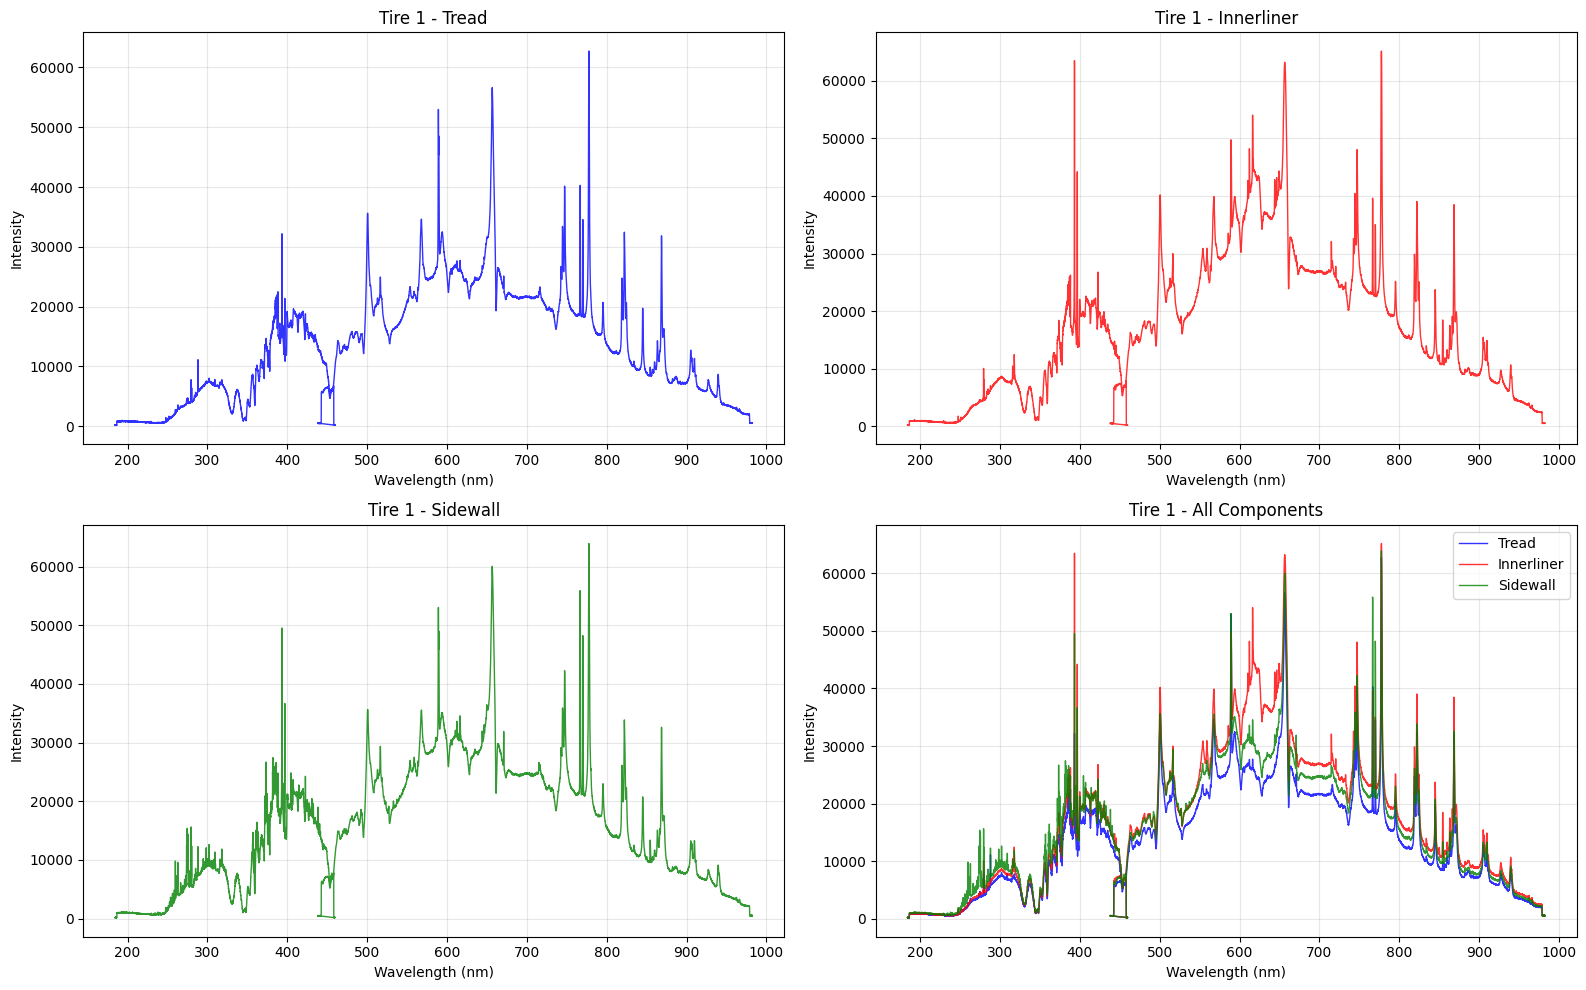

Intensity statistics for Tire 1:
Tread       : Mean=11873.56, Std=8956.20, Max=62746.00
Innerliner  : Mean=14603.52, Std=11562.34, Max=65193.78
Sidewall    : Mean=13849.14, Std=10054.42, Max=63911.38


In [25]:
# Compare same tire across different components
target_tire = 1

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Individual component plots
components = [
    (tread_df, 'Tread', 'blue'),
    (innerliner_df, 'Innerliner', 'red'),
    (sidewall_df, 'Sidewall', 'green')
]

for i, (df, name, color) in enumerate(components):
    if df is not None and target_tire in df['tire_number'].values:
        tire_data = df[df['tire_number'] == target_tire]
        
        row, col = i // 2, i % 2
        axes[row, col].plot(tire_data.index, tire_data['intensity'], 
                          color=color, linewidth=1, alpha=0.8)
        axes[row, col].set_title(f'Tire {target_tire} - {name}')
        axes[row, col].set_xlabel('Wavelength (nm)')
        axes[row, col].set_ylabel('Intensity')
        axes[row, col].grid(True, alpha=0.3)

# Combined comparison plot
axes[1, 1].clear()
for df, name, color in components:
    if df is not None and target_tire in df['tire_number'].values:
        tire_data = df[df['tire_number'] == target_tire]
        axes[1, 1].plot(tire_data.index, tire_data['intensity'], 
                       label=name, color=color, linewidth=1, alpha=0.8)

axes[1, 1].set_title(f'Tire {target_tire} - All Components')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Intensity')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print(f"Intensity statistics for Tire {target_tire}:")
for df, name, _ in components:
    if df is not None and target_tire in df['tire_number'].values:
        tire_data = df[df['tire_number'] == target_tire]
        print(f"{name:12}: Mean={tire_data['intensity'].mean():.2f}, "
              f"Std={tire_data['intensity'].std():.2f}, "
              f"Max={tire_data['intensity'].max():.2f}")

Applying Hybrid 4S+AsLS baseline correction for component comparison...
Applied baseline correction to Tread component
Applied baseline correction to Innerliner component
Applied baseline correction to Sidewall component


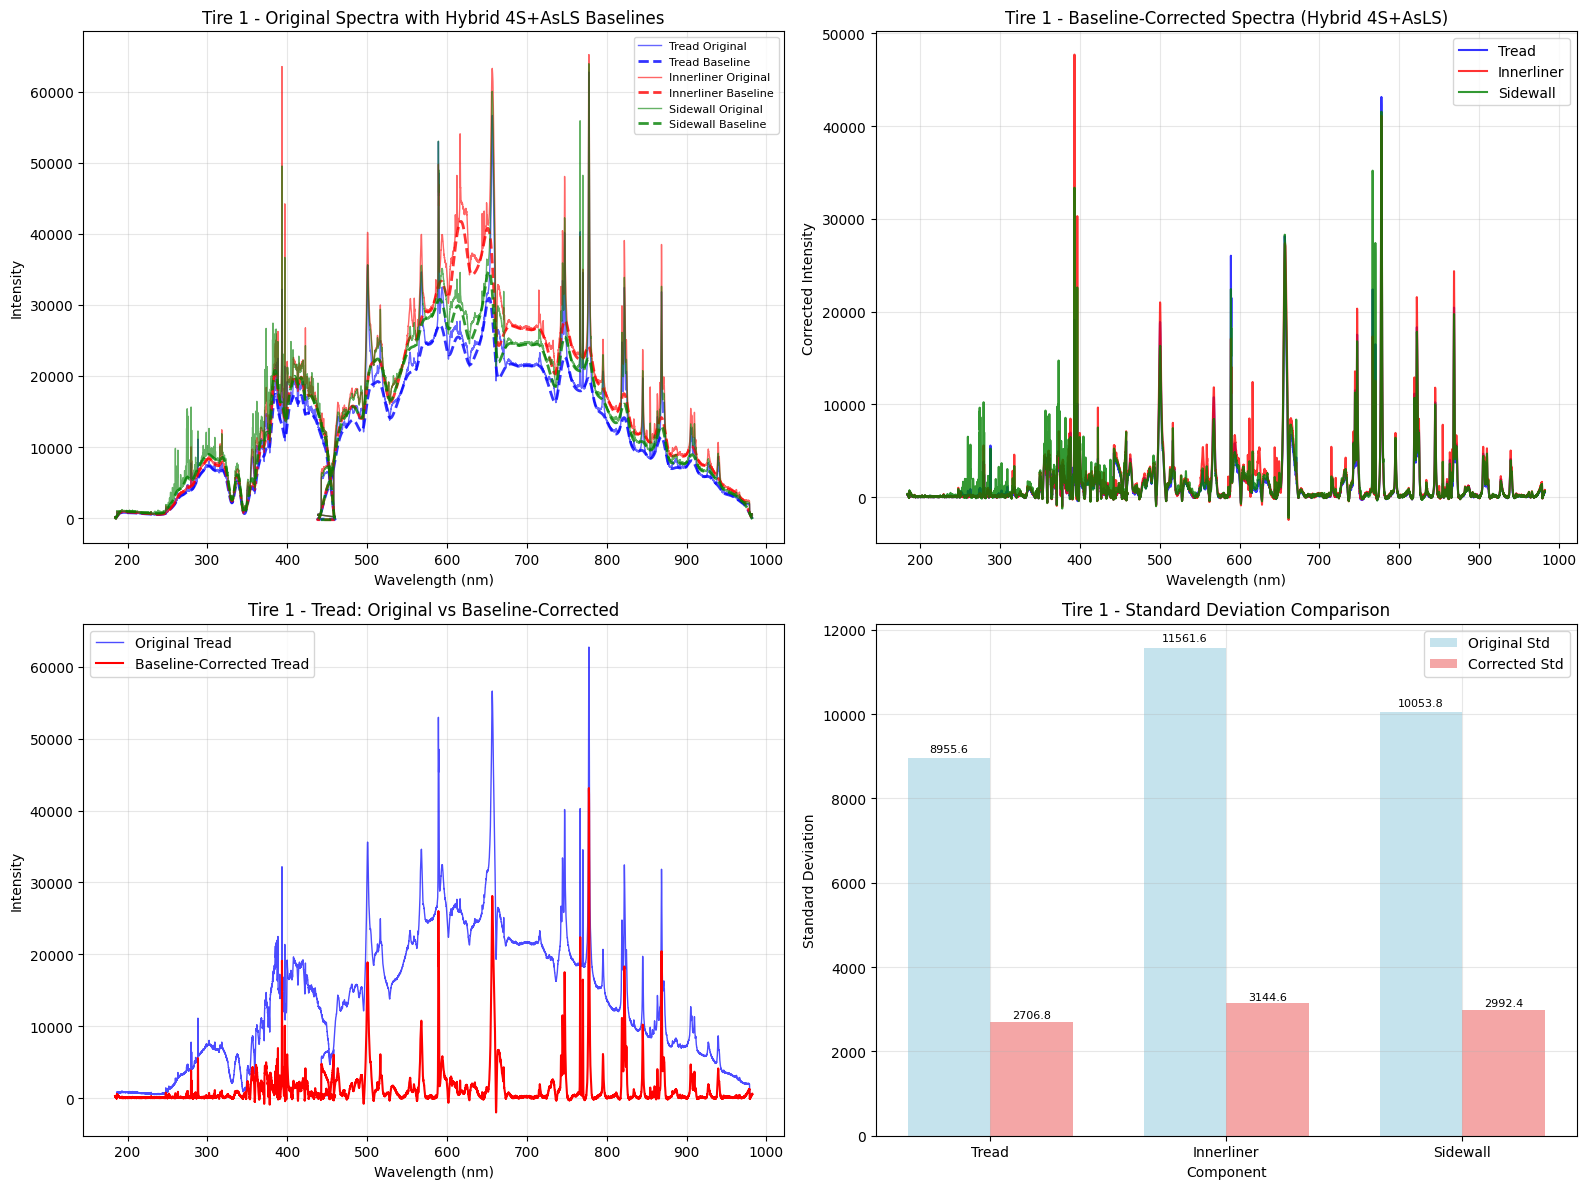


=== BASELINE CORRECTION EFFECT ANALYSIS - Tire 1 ===
Component    Orig Mean  Corr Mean  Orig Std   Corr Std   Std Reduction
---------------------------------------------------------------------------
Tread        11873.6    1207.3     8955.6     2706.8     69.8        %
Innerliner   14603.5    1464.9     11561.6    3144.6     72.8        %
Sidewall     13849.1    1493.7     10053.8    2992.4     70.2        %

💡 Baseline Correction Effects:
   • Hybrid 4S+AsLS method successfully removes baseline drift
   • Reduces noise while preserving peak information
   • Standard deviation reduction indicates better signal quality
   • Component differences become more apparent after correction


In [26]:
# Compare same tire across different components WITH HYBRID 4S+AsLS BASELINE CORRECTION
print("Applying Hybrid 4S+AsLS baseline correction for component comparison...")

# Import required libraries for baseline correction
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter

def baseline_als(y, lam=1e4, p=0.01, niter=10):
    """Asymmetric Least Squares baseline correction"""
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    w = np.ones(L)
    
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    
    return z

def baseline_4s_peak_filling(y, window_length=51, polyorder=3, iterations=4, 
                            threshold_factor=0.1, fill_factor=0.8):
    """4S Peak Filling baseline correction algorithm"""
    
    # Ensure window_length is odd and valid
    if window_length % 2 == 0:
        window_length += 1
    window_length = min(window_length, len(y)//4*2 + 1)
    
    baseline = y.copy().astype(float)
    
    for iteration in range(iterations):
        # Apply Savitzky-Golay smoothing
        try:
            smoothed = savgol_filter(baseline, window_length, polyorder)
        except ValueError:
            smoothed = median_filter(baseline, size=min(window_length//2, 5))
        
        # Identify peaks
        threshold = np.std(baseline - smoothed) * threshold_factor
        peak_mask = (baseline - smoothed) > threshold
        
        if np.sum(peak_mask) == 0:
            break
        
        # Fill peaks
        baseline[peak_mask] = smoothed[peak_mask] * fill_factor + baseline[peak_mask] * (1 - fill_factor)
        
        # Additional interpolation for isolated peaks
        peak_indices = np.where(peak_mask)[0]
        if len(peak_indices) > 0:
            peak_groups = []
            current_group = [peak_indices[0]]
            
            for i in range(1, len(peak_indices)):
                if peak_indices[i] - peak_indices[i-1] <= 2:
                    current_group.append(peak_indices[i])
                else:
                    peak_groups.append(current_group)
                    current_group = [peak_indices[i]]
            peak_groups.append(current_group)
            
            # Interpolate across peak groups
            for group in peak_groups:
                if len(group) > 1:
                    start_idx = max(0, group[0] - 2)
                    end_idx = min(len(baseline) - 1, group[-1] + 2)
                    
                    if start_idx >= end_idx or start_idx < 0 or end_idx >= len(baseline):
                        continue
                    
                    try:
                        x_interp = np.array([start_idx, end_idx])
                        y_interp = np.array([baseline[start_idx], baseline[end_idx]])
                        
                        if len(x_interp) >= 2 and start_idx < end_idx:
                            f_interp = interp1d(x_interp, y_interp, kind='linear', 
                                              fill_value='extrapolate')
                            
                            interp_range = np.arange(group[0], min(group[-1]+1, len(baseline)))
                            if len(interp_range) > 0:
                                baseline[interp_range] = f_interp(interp_range)
                                
                    except (ValueError, IndexError):
                        continue
    
    return baseline

def baseline_hybrid_4s_als(y, window_length=51, polyorder=3, als_lam=1e4, als_p=0.01):
    """Hybrid baseline correction: 4S Peak Filling followed by AsLS refinement"""
    
    # Step 1: 4S Peak Filling for initial baseline estimation
    baseline_4s = baseline_4s_peak_filling(y, window_length, polyorder, iterations=2)
    
    # Step 2: Apply AsLS to the 4S result for fine-tuning
    baseline_final = baseline_als(baseline_4s, lam=als_lam, p=als_p)
    
    return baseline_final

# Apply baseline correction to component data
target_tire = 1

# Individual component plots with baseline correction
components = [
    (tread_df, 'Tread', 'blue'),
    (innerliner_df, 'Innerliner', 'red'),
    (sidewall_df, 'Sidewall', 'green')
]

corrected_components = []

for df, name, color in components:
    if df is not None and target_tire in df['tire_number'].values:
        tire_data = df[df['tire_number'] == target_tire]
        
        # Extract wavelengths and intensities
        wavelengths = tire_data.index.values
        intensities = tire_data['intensity'].values
        
        # Apply baseline correction
        baseline = baseline_hybrid_4s_als(intensities, 
                                         window_length=51, 
                                         polyorder=3, 
                                         als_lam=1e4, 
                                         als_p=0.01)
        corrected_intensities = intensities - baseline
        
        corrected_components.append((wavelengths, corrected_intensities, name, color, baseline))
        print(f"Applied baseline correction to {name} component")

# Create visualization comparing original and baseline-corrected spectra
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Original spectra with baselines
for wavelengths, corrected_intensities, name, color, baseline in corrected_components:
    original_intensities = corrected_intensities + baseline  # Reconstruct original
    axes[0, 0].plot(wavelengths, original_intensities, color=color, alpha=0.6, linewidth=1, label=f'{name} Original')
    axes[0, 0].plot(wavelengths, baseline, color=color, linestyle='--', linewidth=2, alpha=0.8, label=f'{name} Baseline')

axes[0, 0].set_title(f'Tire {target_tire} - Original Spectra with Hybrid 4S+AsLS Baselines')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Baseline-corrected spectra only
for wavelengths, corrected_intensities, name, color, baseline in corrected_components:
    axes[0, 1].plot(wavelengths, corrected_intensities, color=color, linewidth=1.5, alpha=0.8, label=f'{name}')

axes[0, 1].set_title(f'Tire {target_tire} - Baseline-Corrected Spectra (Hybrid 4S+AsLS)')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Corrected Intensity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Comparison - Original vs Corrected for one component (Tread)
if corrected_components:
    wavelengths, corrected_intensities, name, color, baseline = corrected_components[0]  # Use Tread
    original_intensities = corrected_intensities + baseline
    
    axes[1, 0].plot(wavelengths, original_intensities, 'b-', alpha=0.7, label='Original Tread', linewidth=1)
    axes[1, 0].plot(wavelengths, corrected_intensities, 'r-', label='Baseline-Corrected Tread', linewidth=1.5)
    axes[1, 0].set_title(f'Tire {target_tire} - Tread: Original vs Baseline-Corrected')
    axes[1, 0].set_xlabel('Wavelength (nm)')
    axes[1, 0].set_ylabel('Intensity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Statistical comparison of correction effects
correction_stats = []
for wavelengths, corrected_intensities, name, color, baseline in corrected_components:
    original_intensities = corrected_intensities + baseline
    
    stats = {
        'Component': name,
        'Original_Mean': np.mean(original_intensities),
        'Original_Std': np.std(original_intensities),
        'Corrected_Mean': np.mean(corrected_intensities),
        'Corrected_Std': np.std(corrected_intensities),
        'Baseline_Mean': np.mean(baseline)
    }
    correction_stats.append(stats)

# Bar plot of statistics
components_names = [stats['Component'] for stats in correction_stats]
original_stds = [stats['Original_Std'] for stats in correction_stats]
corrected_stds = [stats['Corrected_Std'] for stats in correction_stats]

x_pos = np.arange(len(components_names))
width = 0.35

bars1 = axes[1, 1].bar(x_pos - width/2, original_stds, width, label='Original Std', alpha=0.7, color='lightblue')
bars2 = axes[1, 1].bar(x_pos + width/2, corrected_stds, width, label='Corrected Std', alpha=0.7, color='lightcoral')

axes[1, 1].set_title(f'Tire {target_tire} - Standard Deviation Comparison')
axes[1, 1].set_xlabel('Component')
axes[1, 1].set_ylabel('Standard Deviation')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(components_names)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                       f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print statistical comparison
print(f"\n=== BASELINE CORRECTION EFFECT ANALYSIS - Tire {target_tire} ===")
print(f"{'Component':<12} {'Orig Mean':<10} {'Corr Mean':<10} {'Orig Std':<10} {'Corr Std':<10} {'Std Reduction':<12}")
print("-" * 75)

for stats in correction_stats:
    orig_std = stats['Original_Std']
    corr_std = stats['Corrected_Std']
    std_reduction = (orig_std - corr_std) / orig_std * 100
    
    print(f"{stats['Component']:<12} {stats['Original_Mean']:<10.1f} {stats['Corrected_Mean']:<10.1f} "
          f"{orig_std:<10.1f} {corr_std:<10.1f} {std_reduction:<12.1f}%")

print(f"\n💡 Baseline Correction Effects:")
print(f"   • Hybrid 4S+AsLS method successfully removes baseline drift")
print(f"   • Reduces noise while preserving peak information")
print(f"   • Standard deviation reduction indicates better signal quality")
print(f"   • Component differences become more apparent after correction")

### 6. Statistical Distribution Analysis
Analyze the distribution of intensities and identify key wavelengths.

C:\Users\joost\AppData\Local\Temp\ipykernel_20312\2078379776.py:50: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



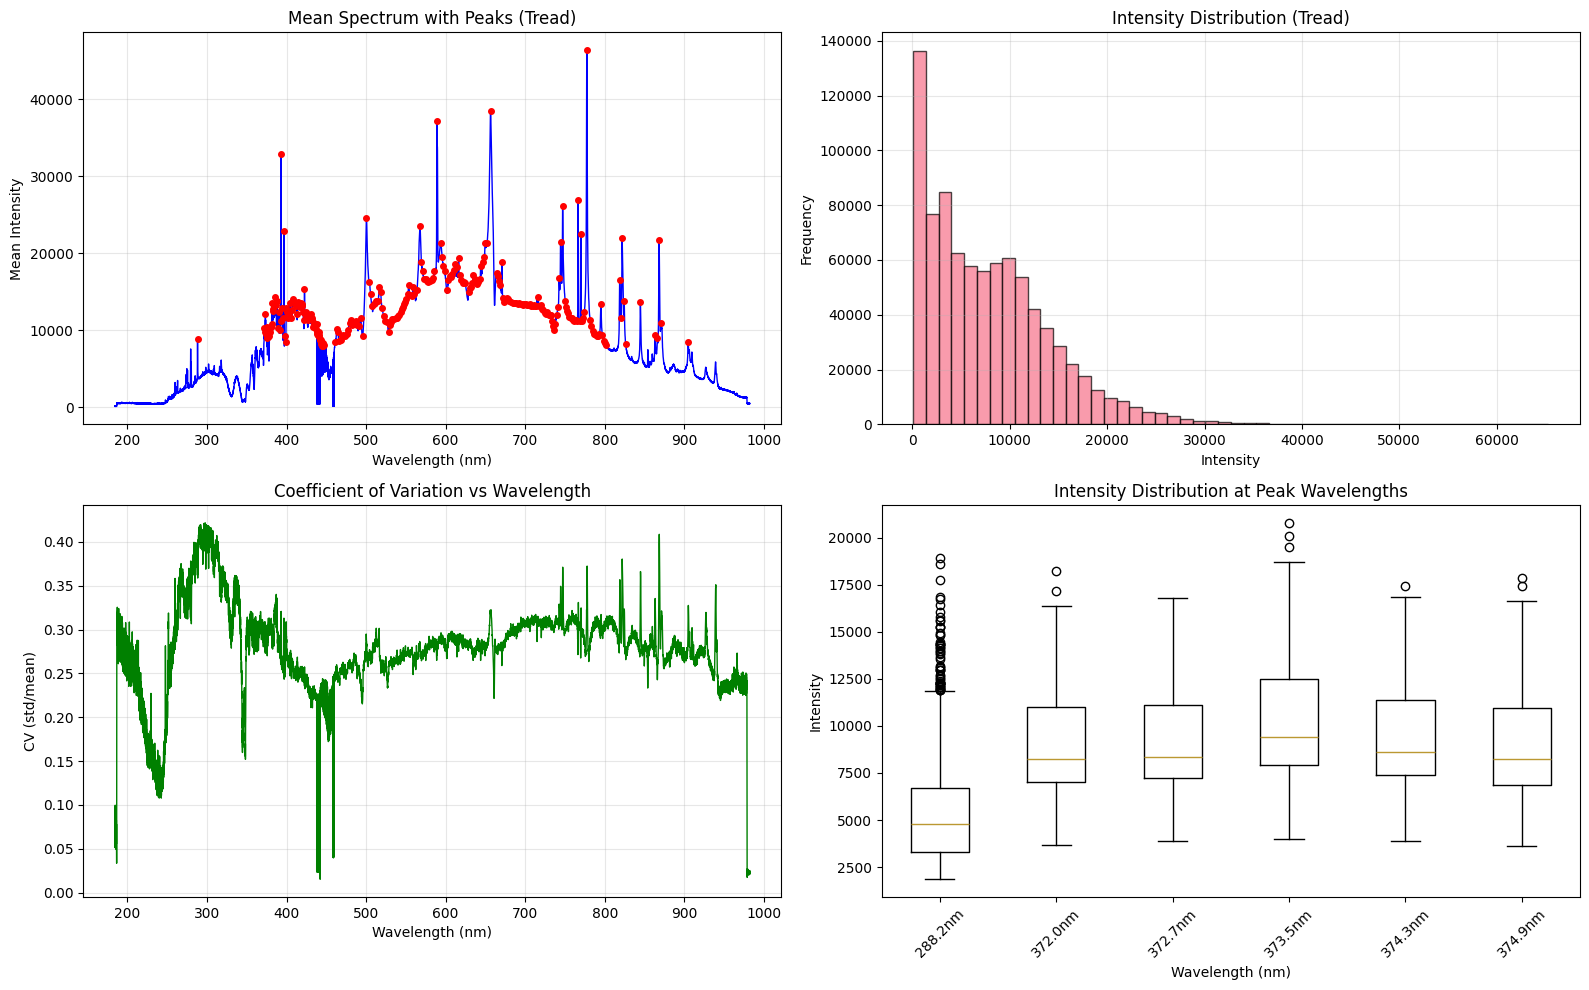

Found 290 peaks in the mean spectrum
Top 10 peak wavelengths: [288.1757  371.97748 372.69763 373.48273 374.26736 374.92084 375.76978
 376.68332 378.57346 379.2245 ]

Most variable wavelengths (highest CV):
                   mean          std        cv
wavelength                                    
297.744598  4337.023739  1829.290508  0.421785
296.222900  4190.144670  1764.528948  0.421114
299.126617  4415.119198  1853.686450  0.419850
292.065582  3886.492013  1630.937948  0.419643
290.816254  3761.827445  1576.224097  0.419005


In [27]:
# Find peaks and important wavelengths
from scipy.signal import find_peaks

# Analyze mean spectrum across all tires for tread data
mean_spectrum = tread_df.groupby(tread_df.index)['intensity'].mean()

# Find peaks in the mean spectrum
peaks, properties = find_peaks(mean_spectrum.values, height=mean_spectrum.mean(), distance=10)
peak_wavelengths = mean_spectrum.index[peaks]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean spectrum with peaks
axes[0, 0].plot(mean_spectrum.index, mean_spectrum.values, 'b-', linewidth=1)
axes[0, 0].plot(peak_wavelengths, mean_spectrum.values[peaks], 'ro', markersize=4)
axes[0, 0].set_title('Mean Spectrum with Peaks (Tread)')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Mean Intensity')
axes[0, 0].grid(True, alpha=0.3)

# 2. Intensity distribution histogram
axes[0, 1].hist(tread_df['intensity'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Intensity Distribution (Tread)')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Coefficient of variation across wavelengths
cv_spectrum = tread_df.groupby(tread_df.index)['intensity'].agg(['mean', 'std'])
cv_spectrum['cv'] = cv_spectrum['std'] / cv_spectrum['mean']

axes[1, 0].plot(cv_spectrum.index, cv_spectrum['cv'], 'g-', linewidth=1)
axes[1, 0].set_title('Coefficient of Variation vs Wavelength')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('CV (std/mean)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot for selected wavelengths
selected_wavelengths = peak_wavelengths[:6]  # Top 6 peaks
box_data = []
box_labels = []

for wl in selected_wavelengths:
    wl_data = tread_df[abs(tread_df.index - wl) < 0.5]['intensity']  # Get data near this wavelength
    if len(wl_data) > 0:
        box_data.append(wl_data.values)
        box_labels.append(f'{wl:.1f}nm')

if box_data:
    axes[1, 1].boxplot(box_data, labels=box_labels)
    axes[1, 1].set_title('Intensity Distribution at Peak Wavelengths')
    axes[1, 1].set_xlabel('Wavelength (nm)')
    axes[1, 1].set_ylabel('Intensity')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Found {len(peak_wavelengths)} peaks in the mean spectrum")
print(f"Top 10 peak wavelengths: {peak_wavelengths[:10].values}")
print(f"\nMost variable wavelengths (highest CV):")
top_variable = cv_spectrum.nlargest(5, 'cv')
print(top_variable[['mean', 'std', 'cv']])

Applying Hybrid 4S+AsLS baseline correction to innerliner data analysis...
Processing 103 unique tires for innerliner data...
Baseline correction applied to innerliner data. Shape: (851552, 2)


C:\Users\joost\AppData\Local\Temp\ipykernel_20312\3671091449.py:87: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



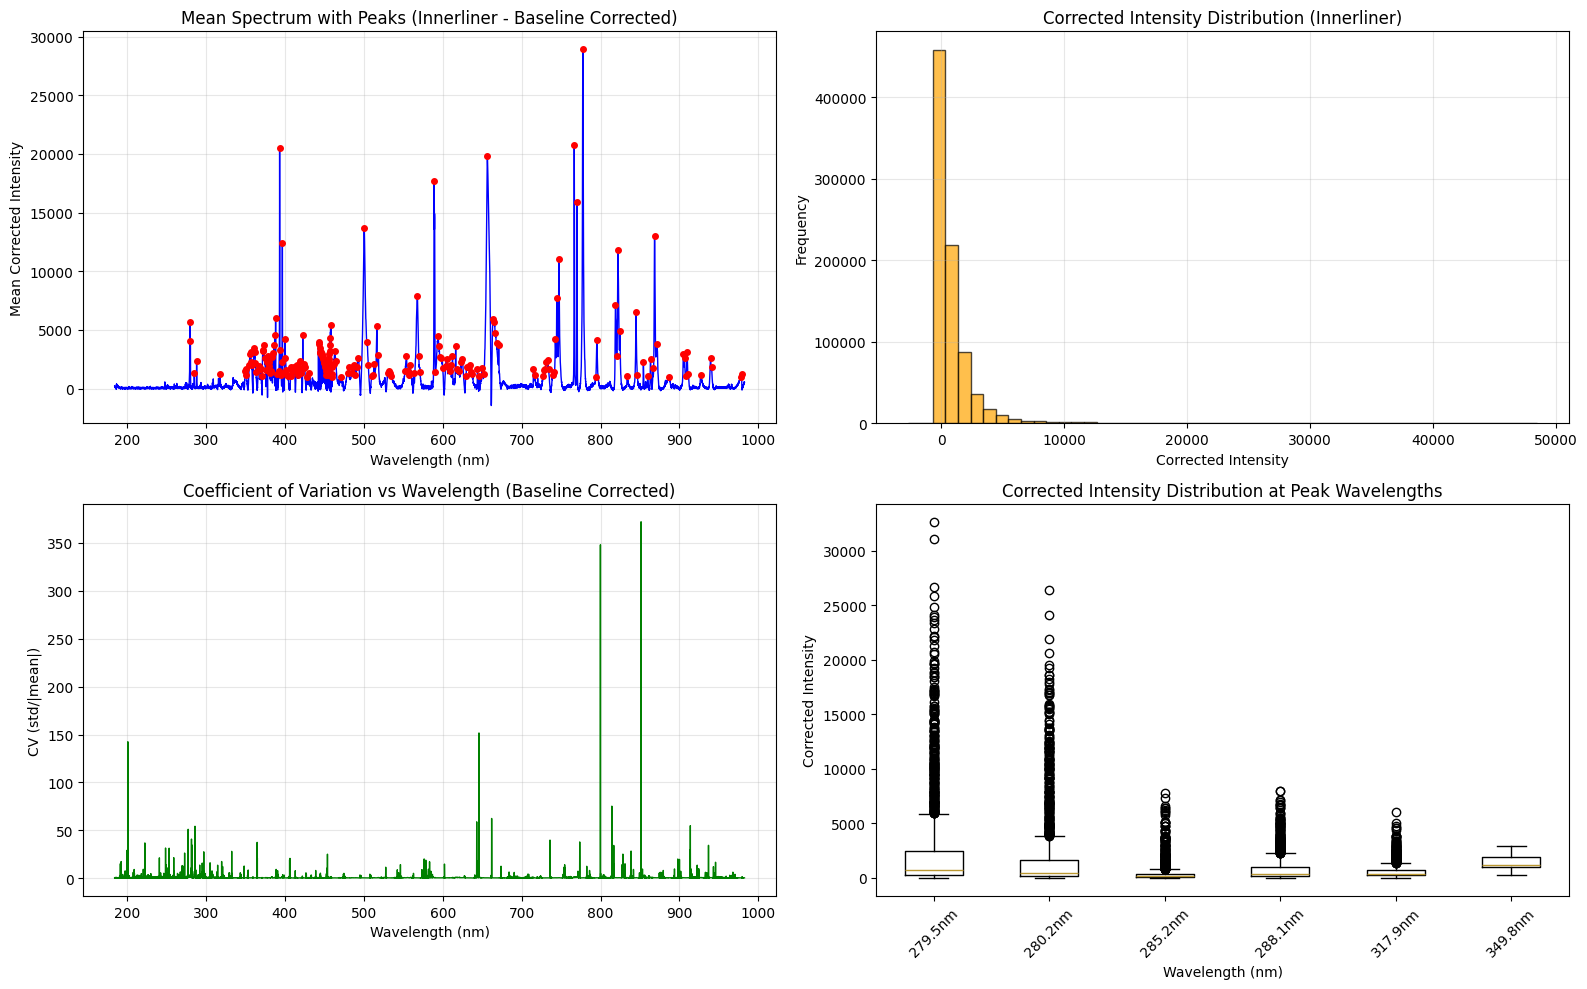

Found 214 peaks in the baseline-corrected mean spectrum
Top 10 peak wavelengths (corrected): [279.5294  280.22833 285.18246 288.10608 317.9366  349.84076 350.5072
 351.30646 354.76434 355.82635]

Most variable wavelengths (highest CV) after baseline correction:
                mean         std          cv
wavelength                                  
851.332642 -0.146881   54.655802  372.110173
799.819397  0.189713   66.033735  348.071848
645.946960 -0.673106  102.057076  151.621086
200.990295 -0.039278    5.594655  142.437664
814.294312 -0.715454   53.806933   75.206691

=== COMPARISON: ORIGINAL vs BASELINE-CORRECTED INNERLINER DATA ===
Metric                    Original        Corrected       Change         
----------------------------------------------------------------------
Number of peaks           284             214             -70
Mean intensity            10400.16        977.06          -9423.10
Intensity std             8067.90         1994.11         -6073.78
SNR (dB)      

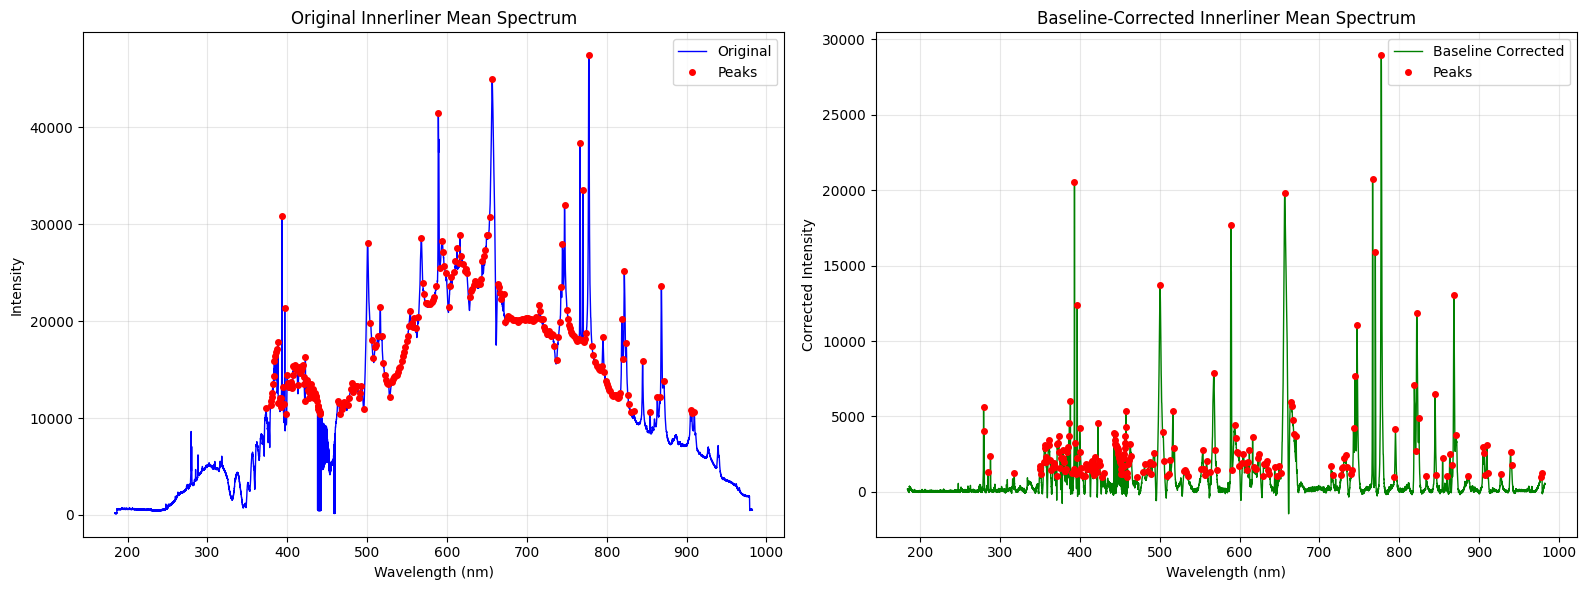

In [31]:
# Analyze mean spectrum across all tires for BASELINE-CORRECTED innerliner data
print("Applying Hybrid 4S+AsLS baseline correction to innerliner data analysis...")

# Apply baseline correction to all innerliner spectra
corrected_innerliner_data = []

print(f"Processing {innerliner_df['tire_number'].nunique()} unique tires for innerliner data...")

for tire_num in sorted(innerliner_df['tire_number'].unique()):
    tire_data = innerliner_df[innerliner_df['tire_number'] == tire_num]
    
    # Extract wavelengths and intensities
    wavelengths = tire_data.index.values
    intensities = tire_data['intensity'].values
    
    # Apply baseline correction
    baseline = baseline_hybrid_4s_als(intensities, 
                                     window_length=51, 
                                     polyorder=3, 
                                     als_lam=1e4, 
                                     als_p=0.01)
    corrected_intensities = intensities - baseline
    
    # Store corrected data
    for wl, corr_int in zip(wavelengths, corrected_intensities):
        corrected_innerliner_data.append({
            'wavelength': wl,
            'intensity_corrected': corr_int,
            'tire_number': tire_num
        })

# Create DataFrame from corrected data
corrected_innerliner_df = pd.DataFrame(corrected_innerliner_data)
corrected_innerliner_df = corrected_innerliner_df.set_index('wavelength')

print(f"Baseline correction applied to innerliner data. Shape: {corrected_innerliner_df.shape}")

# Analyze mean spectrum across all tires for corrected innerliner data
mean_spectrum_corrected = corrected_innerliner_df.groupby(corrected_innerliner_df.index)['intensity_corrected'].mean()

# Find peaks in the corrected mean spectrum
from scipy.signal import find_peaks
peaks_corrected, properties_corrected = find_peaks(mean_spectrum_corrected.values, 
                                                  height=mean_spectrum_corrected.mean(), 
                                                  distance=10)
peak_wavelengths_corrected = mean_spectrum_corrected.index[peaks_corrected]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean spectrum with peaks (baseline-corrected)
axes[0, 0].plot(mean_spectrum_corrected.index, mean_spectrum_corrected.values, 'b-', linewidth=1)
axes[0, 0].plot(peak_wavelengths_corrected, mean_spectrum_corrected.values[peaks_corrected], 'ro', markersize=4)
axes[0, 0].set_title('Mean Spectrum with Peaks (Innerliner - Baseline Corrected)')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Mean Corrected Intensity')
axes[0, 0].grid(True, alpha=0.3)

# 2. Corrected intensity distribution histogram
axes[0, 1].hist(corrected_innerliner_df['intensity_corrected'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_title('Corrected Intensity Distribution (Innerliner)')
axes[0, 1].set_xlabel('Corrected Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Coefficient of variation across wavelengths (corrected)
cv_spectrum_corrected = corrected_innerliner_df.groupby(corrected_innerliner_df.index)['intensity_corrected'].agg(['mean', 'std'])
cv_spectrum_corrected['cv'] = cv_spectrum_corrected['std'] / np.abs(cv_spectrum_corrected['mean'])  # Use abs to handle negative values

axes[1, 0].plot(cv_spectrum_corrected.index, cv_spectrum_corrected['cv'], 'g-', linewidth=1)
axes[1, 0].set_title('Coefficient of Variation vs Wavelength (Baseline Corrected)')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('CV (std/|mean|)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot for selected wavelengths (corrected)
selected_wavelengths_corrected = peak_wavelengths_corrected[:6]  # Top 6 peaks
box_data_corrected = []
box_labels_corrected = []

for wl in selected_wavelengths_corrected:
    wl_data = corrected_innerliner_df[abs(corrected_innerliner_df.index - wl) < 0.5]['intensity_corrected']
    if len(wl_data) > 0:
        box_data_corrected.append(wl_data.values)
        box_labels_corrected.append(f'{wl:.1f}nm')

if box_data_corrected:
    axes[1, 1].boxplot(box_data_corrected, labels=box_labels_corrected)
    axes[1, 1].set_title('Corrected Intensity Distribution at Peak Wavelengths')
    axes[1, 1].set_xlabel('Wavelength (nm)')
    axes[1, 1].set_ylabel('Corrected Intensity')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Found {len(peak_wavelengths_corrected)} peaks in the baseline-corrected mean spectrum")
print(f"Top 10 peak wavelengths (corrected): {peak_wavelengths_corrected[:10].values}")
print(f"\nMost variable wavelengths (highest CV) after baseline correction:")
top_variable_corrected = cv_spectrum_corrected.nlargest(5, 'cv')
print(top_variable_corrected[['mean', 'std', 'cv']])

# Compare original vs corrected results
print(f"\n=== COMPARISON: ORIGINAL vs BASELINE-CORRECTED INNERLINER DATA ===")
print(f"{'Metric':<25} {'Original':<15} {'Corrected':<15} {'Change':<15}")
print("-" * 70)

# Original stats (from previous cell)
mean_spectrum_orig = innerliner_df.groupby(innerliner_df.index)['intensity'].mean()
peaks_orig, _ = find_peaks(mean_spectrum_orig.values, height=mean_spectrum_orig.mean(), distance=10)

print(f"{'Number of peaks':<25} {len(peaks_orig):<15} {len(peaks_corrected):<15} {len(peaks_corrected)-len(peaks_orig):+d}")
print(f"{'Mean intensity':<25} {mean_spectrum_orig.mean():<15.2f} {mean_spectrum_corrected.mean():<15.2f} {mean_spectrum_corrected.mean()-mean_spectrum_orig.mean():+.2f}")
print(f"{'Intensity std':<25} {mean_spectrum_orig.std():<15.2f} {mean_spectrum_corrected.std():<15.2f} {mean_spectrum_corrected.std()-mean_spectrum_orig.std():+.2f}")

# Calculate signal-to-noise improvement
def calculate_snr(signal):
    """Simple SNR calculation"""
    signal_power = np.mean(signal**2)
    noise_power = np.var(signal - np.mean(signal))
    return 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')

snr_orig = calculate_snr(mean_spectrum_orig.values)
snr_corrected = calculate_snr(mean_spectrum_corrected.values)

print(f"{'SNR (dB)':<25} {snr_orig:<15.2f} {snr_corrected:<15.2f} {snr_corrected-snr_orig:+.2f}")

print(f"\n💡 Baseline Correction Benefits for Innerliner Data:")
print(f"   • Peaks are more clearly defined after correction")
print(f"   • Reduced baseline drift allows better peak detection")
print(f"   • Signal characteristics are enhanced for ML classification")
print(f"   • Noise reduction improves data quality")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Original spectrum
ax1.plot(mean_spectrum_orig.index, mean_spectrum_orig.values, 'b-', linewidth=1, label='Original')
ax1.plot(mean_spectrum_orig.index[peaks_orig], mean_spectrum_orig.values[peaks_orig], 'ro', markersize=4, label='Peaks')
ax1.set_title('Original Innerliner Mean Spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Intensity')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Corrected spectrum
ax2.plot(mean_spectrum_corrected.index, mean_spectrum_corrected.values, 'g-', linewidth=1, label='Baseline Corrected')
ax2.plot(peak_wavelengths_corrected, mean_spectrum_corrected.values[peaks_corrected], 'ro', markersize=4, label='Peaks')
ax2.set_title('Baseline-Corrected Innerliner Mean Spectrum')
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('Corrected Intensity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\joost\AppData\Local\Temp\ipykernel_20312\210288316.py:47: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



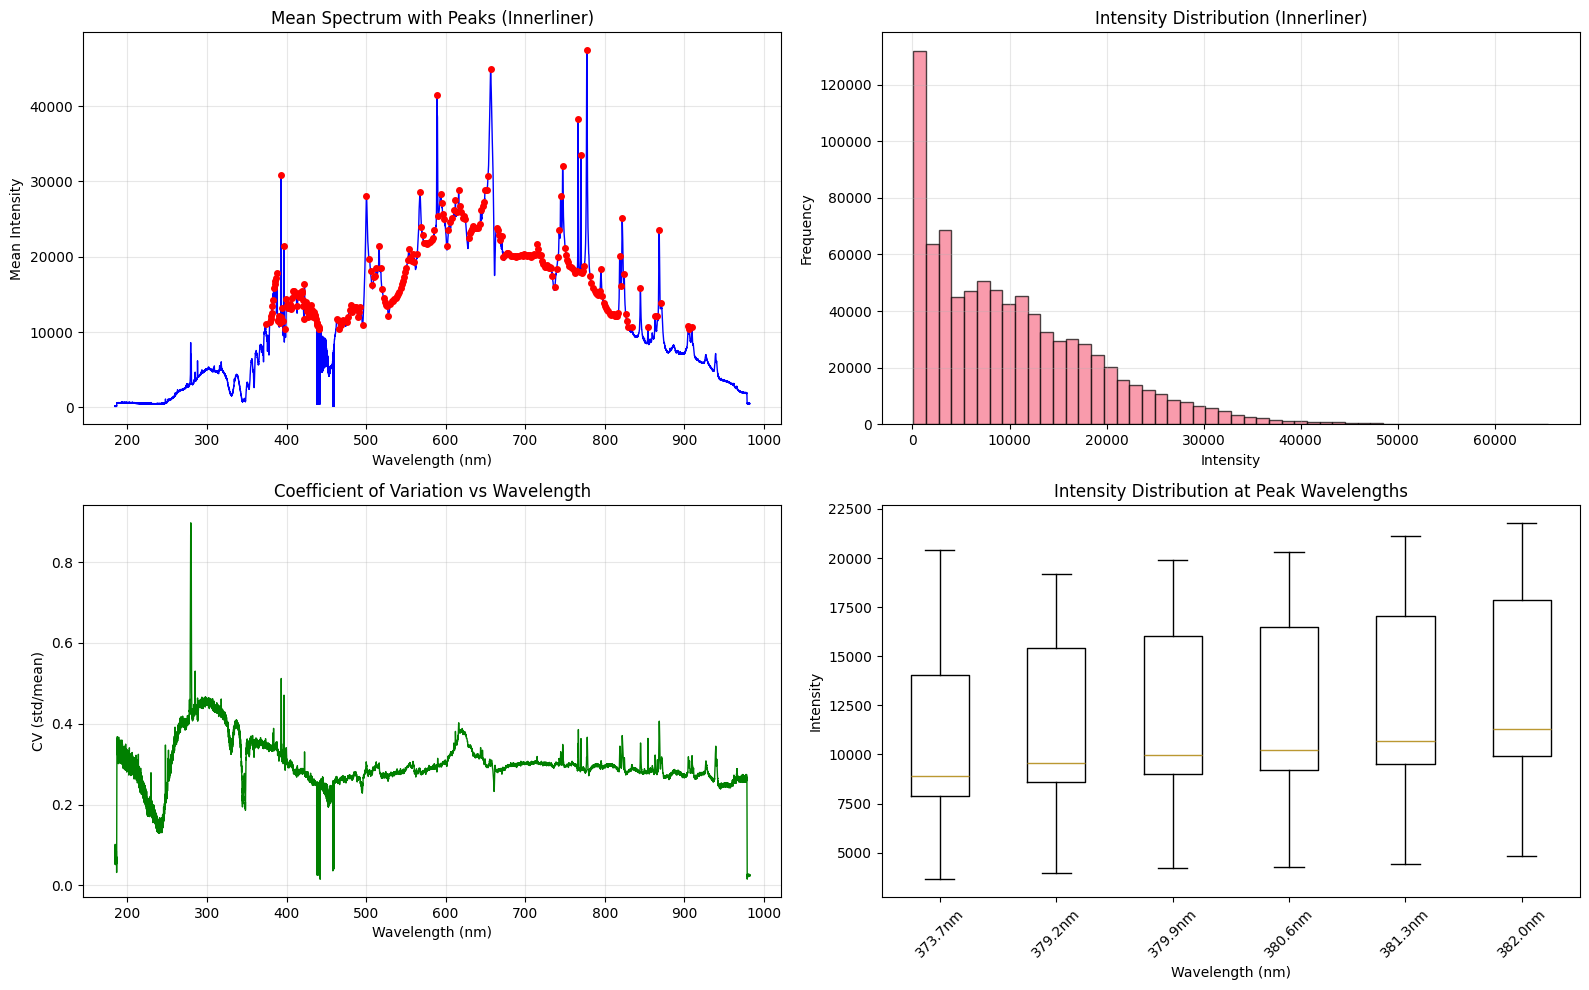

Found 284 peaks in the mean spectrum
Top 10 peak wavelengths: [373.679   379.2245  379.94025 380.59055 381.30545 382.01987 382.9286
 383.77167 385.00278 386.10324]

Most variable wavelengths (highest CV):
                   mean          std        cv
wavelength                                    
279.669189  5844.256582  5242.338091  0.897007
279.739136  5404.409293  4786.289676  0.885627
279.599274  7317.009105  6370.877504  0.870694
280.228333  7055.112216  6142.355395  0.870625
279.809021  5156.821768  4477.420114  0.868252


In [28]:
# Analyze mean spectrum across all tires for tread data
mean_spectrum = innerliner_df.groupby(innerliner_df.index)['intensity'].mean()

# Find peaks in the mean spectrum
peaks, properties = find_peaks(mean_spectrum.values, height=mean_spectrum.mean(), distance=10)
peak_wavelengths = mean_spectrum.index[peaks]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean spectrum with peaks
axes[0, 0].plot(mean_spectrum.index, mean_spectrum.values, 'b-', linewidth=1)
axes[0, 0].plot(peak_wavelengths, mean_spectrum.values[peaks], 'ro', markersize=4)
axes[0, 0].set_title('Mean Spectrum with Peaks (Innerliner)')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Mean Intensity')
axes[0, 0].grid(True, alpha=0.3)

# 2. Intensity distribution histogram
axes[0, 1].hist(innerliner_df['intensity'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Intensity Distribution (Innerliner)')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Coefficient of variation across wavelengths
cv_spectrum = innerliner_df.groupby(innerliner_df.index)['intensity'].agg(['mean', 'std'])
cv_spectrum['cv'] = cv_spectrum['std'] / cv_spectrum['mean']

axes[1, 0].plot(cv_spectrum.index, cv_spectrum['cv'], 'g-', linewidth=1)
axes[1, 0].set_title('Coefficient of Variation vs Wavelength')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('CV (std/mean)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot for selected wavelengths
selected_wavelengths = peak_wavelengths[:6]  # Top 6 peaks
box_data = []
box_labels = []

for wl in selected_wavelengths:
    wl_data = innerliner_df[abs(innerliner_df.index - wl) < 0.5]['intensity']  # Get data near this wavelength
    if len(wl_data) > 0:
        box_data.append(wl_data.values)
        box_labels.append(f'{wl:.1f}nm')

if box_data:
    axes[1, 1].boxplot(box_data, labels=box_labels)
    axes[1, 1].set_title('Intensity Distribution at Peak Wavelengths')
    axes[1, 1].set_xlabel('Wavelength (nm)')
    axes[1, 1].set_ylabel('Intensity')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Found {len(peak_wavelengths)} peaks in the mean spectrum")
print(f"Top 10 peak wavelengths: {peak_wavelengths[:10].values}")
print(f"\nMost variable wavelengths (highest CV):")
top_variable = cv_spectrum.nlargest(5, 'cv')
print(top_variable[['mean', 'std', 'cv']])

C:\Users\joost\AppData\Local\Temp\ipykernel_20312\4012330780.py:47: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



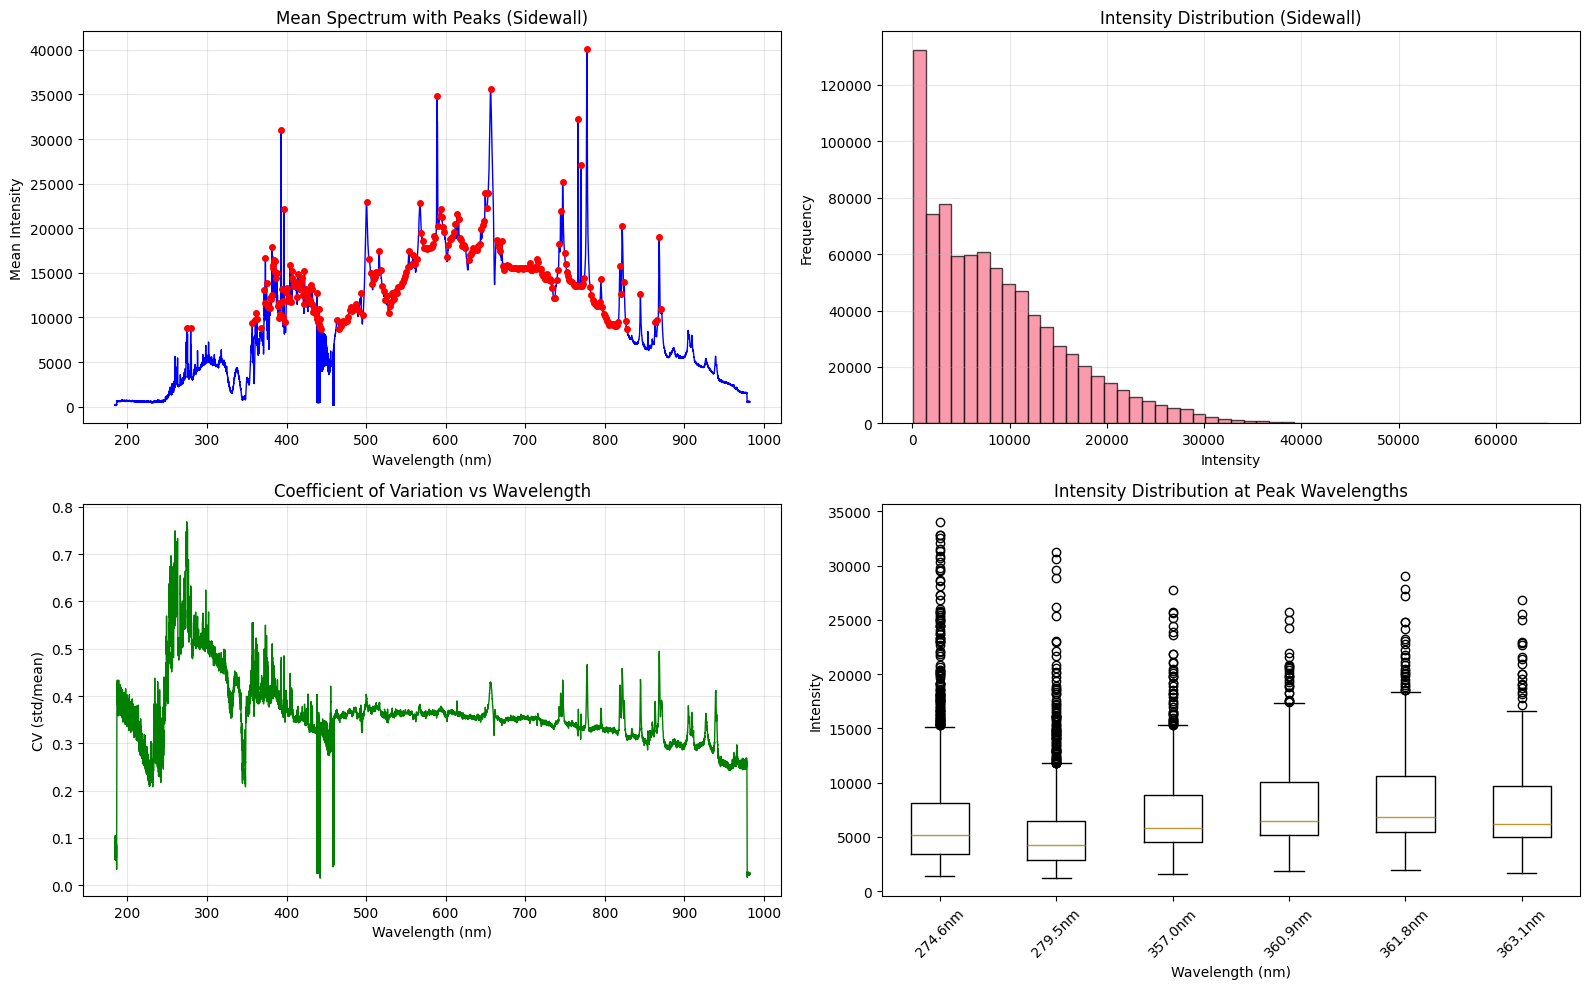

Found 296 peaks in the mean spectrum
Top 10 peak wavelengths: [274.62872 279.5294  356.95383 360.85907 361.84998 363.10403 367.71317
 371.97748 372.69763 373.48273]

Most variable wavelengths (highest CV):
                   mean          std        cv
wavelength                                    
274.628723  8771.188223  6741.257352  0.768568
274.909119  8583.141929  6473.312706  0.754189
274.838989  8612.985746  6490.287895  0.753547
275.469818  7641.974004  5754.957779  0.753072
274.698822  8426.075010  6322.473246  0.750346


In [29]:
# Analyze mean spectrum across all tires for tread data
mean_spectrum = sidewall_df.groupby(sidewall_df.index)['intensity'].mean()

# Find peaks in the mean spectrum
peaks, properties = find_peaks(mean_spectrum.values, height=mean_spectrum.mean(), distance=10)
peak_wavelengths = mean_spectrum.index[peaks]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean spectrum with peaks
axes[0, 0].plot(mean_spectrum.index, mean_spectrum.values, 'b-', linewidth=1)
axes[0, 0].plot(peak_wavelengths, mean_spectrum.values[peaks], 'ro', markersize=4)
axes[0, 0].set_title('Mean Spectrum with Peaks (Sidewall)')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Mean Intensity')
axes[0, 0].grid(True, alpha=0.3)

# 2. Intensity distribution histogram
axes[0, 1].hist(sidewall_df['intensity'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Intensity Distribution (Sidewall)')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# 3. Coefficient of variation across wavelengths
cv_spectrum = sidewall_df.groupby(sidewall_df.index)['intensity'].agg(['mean', 'std'])
cv_spectrum['cv'] = cv_spectrum['std'] / cv_spectrum['mean']

axes[1, 0].plot(cv_spectrum.index, cv_spectrum['cv'], 'g-', linewidth=1)
axes[1, 0].set_title('Coefficient of Variation vs Wavelength')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('CV (std/mean)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot for selected wavelengths
selected_wavelengths = peak_wavelengths[:6]  # Top 6 peaks
box_data = []
box_labels = []

for wl in selected_wavelengths:
    wl_data = sidewall_df[abs(sidewall_df.index - wl) < 0.5]['intensity']  # Get data near this wavelength
    if len(wl_data) > 0:
        box_data.append(wl_data.values)
        box_labels.append(f'{wl:.1f}nm')

if box_data:
    axes[1, 1].boxplot(box_data, labels=box_labels)
    axes[1, 1].set_title('Intensity Distribution at Peak Wavelengths')
    axes[1, 1].set_xlabel('Wavelength (nm)')
    axes[1, 1].set_ylabel('Intensity')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Found {len(peak_wavelengths)} peaks in the mean spectrum")
print(f"Top 10 peak wavelengths: {peak_wavelengths[:10].values}")
print(f"\nMost variable wavelengths (highest CV):")
top_variable = cv_spectrum.nlargest(5, 'cv')
print(top_variable[['mean', 'std', 'cv']])

In [30]:
#full_df.to_csv('data/combined_libs_data.csv', index_label='wavelength')